## Overview

In this assignment you will work with real ocean data from a single Argo profiling float
of your choosing.  You will produce a series of plots and short written analyses.

### What to hand in
If you are comfortable with python, try editing this notebook, writing your answers in markdown cells. You can export the notebook as a pdf file.
Otherwise, feel free to save the output of your figures as images, and add them into a document with your explanations.


### Tasks at a glance
1. Plot the float trajectory on a map
2. Contour plots of temperature and salinity (depth vs. time)
3. Mixed layer depth from density — plot over time
4. Average mixed-layer properties over time

---

## Float selection

Before running any code:

1. Open the [Euro-Argo Fleet Monitor](https://fleetmonitoring.euro-argo.eu/)
2. Find a float with **at least one year of measurements**
3. Note its **WMO number** and enter it in the Setup cell below

> **Tip:** Clicking a float on the map shows its WMO number, deployment date, and number
> of profiles. Choose one with 50+ profiles to see clear seasonal patterns.

---
## Setup

In [61]:
# Standard imports — do not change these
from argopy import DataFetcher as ArgoDataFetcher

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [62]:
# Choose your float!
WMO = 7902194

In the cell below, download your data! Check the exercises to see how we did before

In [63]:
# Add your data download function
# Download data from the Argo ERDDAP server
print(f'Downloading data for float {WMO} ...')
loader = ArgoDataFetcher(src='erddap').float(WMO)

# argopy returns an xarray Dataset — we convert it to a pandas DataFrame
# which is easier to work with if you are new to Python
ds  = loader.to_xarray()       # xarray Dataset
df  = ds.to_dataframe().reset_index()   # pandas DataFrame

print(f'Download complete!  {len(df):,} data points retrieved.')

Download complete!  20,792 data points retrieved.


---
## Task 1 — Float Trajectory Map

Plot the path the float took through the ocean.  Each point shoud represents one profile. Try having some fun and making the plot easy to understand

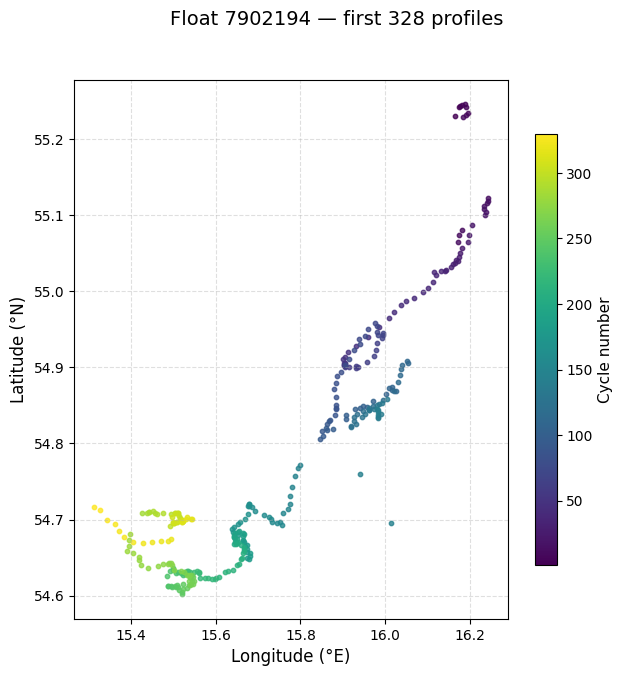

In [64]:
## Add your plotting code here, remember you can save outputs of figures locally
plt.show()
# Start by creating a figure
fig, ax = plt.subplots(figsize=(7, 7))

# make sure we have sorted everything by time
df = df.sort_values("TIME")

# get the lat and lons of each measurment, but only save the first one! otherwise we'll get a lot of points for each row in our dataframe
df_cycles = df.groupby("CYCLE_NUMBER")[["LATITUDE", "LONGITUDE"]].first().reset_index()
latitudes = df_cycles["LATITUDE"]
longitudes = df_cycles["LONGITUDE"]

# and get the cycle numbers
cycle_numbers = df_cycles["CYCLE_NUMBER"]
# Create a color map for each cycle
cycles_to_plot = cycle_numbers.unique()
norm = plt.Normalize(vmin=cycle_numbers.min(), vmax=cycle_numbers.max())
colours = plt.cm.viridis(norm(cycle_numbers))

# Plot each point
for color, lat, lon in zip(colours, latitudes, longitudes):
    ax.scatter(lon, lat, color=color, s=10, alpha=0.8)

# Add a colourbar to show which cycle is which
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(vmin=cycle_numbers.min(), vmax=cycle_numbers.max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label('Cycle number', fontsize=11)

fig.suptitle(f'Float {WMO} — first {len(cycles_to_plot)} profiles', fontsize=14)
ax.set_xlabel('Longitude (°E)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

**Any Comments?**

(You can edit this markdown cell)

---
## Task 2 — Contour Plots (Temperature and Salinity)

A contour plot shows **depth on the y-axis**, **time on the x-axis**,
and a measured variable as **colour**.  It reveals how the water column changes
throughout the year in one compact figure.

Checkout the notebooks to figure out how to do this. **hint**, you'll first need to create a regular grid of pressure levels, and then interpolate the data onto it. Check out notebook 1 for more details. Play around with the visulalations and color maps!



In [65]:
# Add your code here
# Drop rows that are missing a temperature, salinity, or pressure value
df = df.dropna(subset=['TEMP', 'PSAL', 'PRES'])

print(f'Rows after cleaning: {len(df):,}')

Rows after cleaning: 20,792


In [66]:
# ---------------------------------------------------------------
# Parameters you can adjust
# ---------------------------------------------------------------
PRES_MIN   =   0    # Shallow end (dbar)
PRES_MAX   =  50    # Deep end — reduce to 200 to focus on the surface layer
PRES_STEP  =   5    # Vertical resolution of the output grid (dbar)
# ---------------------------------------------------------------

# Get a sorted list of cycle numbers and corresponding dates
# We use the median date of each cycle as the time axis value
cycle_times = (
    df.groupby('CYCLE_NUMBER')['TIME']
    .median()
    .reset_index()
    .rename(columns={'TIME': 'DATE'})
)

# Merge the date back onto the main DataFrame
df = df.merge(cycle_times, on='CYCLE_NUMBER')

# Regular pressure axis
pres_grid = np.arange(PRES_MIN, PRES_MAX + PRES_STEP, PRES_STEP)


def interpolate_profiles(df, variable, pres_grid):
    """
    Interpolate a variable onto a regular pressure grid for every cycle.

    Returns
    -------
    grid_data  : 2-D numpy array  shape (len(pres_grid), n_cycles)
    dates      : 1-D array of datetime objects for each cycle (x-axis)
    """
    cycles = sorted(df['CYCLE_NUMBER'].unique())
    dates  = []
    grid_data = np.full((len(pres_grid), len(cycles)), np.nan)

    for col_idx, cycle in enumerate(cycles):
        profile = (
            df[df['CYCLE_NUMBER'] == cycle]
            .dropna(subset=[variable, 'PRES'])
            .sort_values('PRES')
        )
        if len(profile) < 3:
            continue   # Skip cycles with too few points

        # Linear interpolation onto the regular pressure axis
        interpolated = np.interp(
            pres_grid,
            profile['PRES'].values,
            profile[variable].values,
            left=np.nan, right=np.nan
        )
        grid_data[:, col_idx] = interpolated
        dates.append(profile['DATE'].iloc[0])

    return grid_data, np.array(dates)


# Build the 2-D grids for temperature and salinity
temp_grid, dates = interpolate_profiles(df, 'TEMP', pres_grid)
psal_grid, _     = interpolate_profiles(df, 'PSAL', pres_grid)

print(f'Grid shape (depth × time): {temp_grid.shape}')

Grid shape (depth × time): (11, 328)


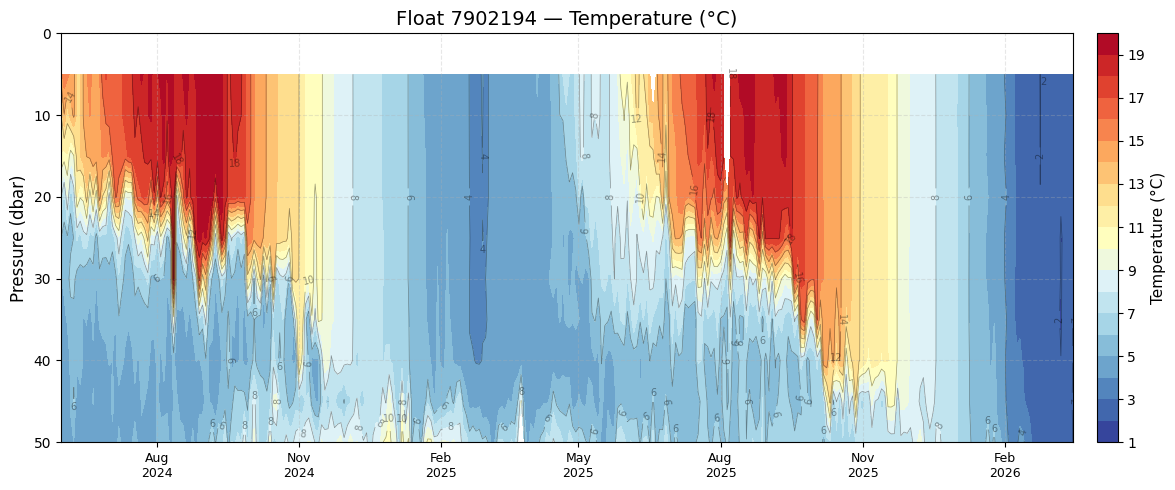

In [67]:
fig, ax = plt.subplots(figsize=(13, 5))

# Filled contour plot
cf = ax.contourf(
    dates,          # x-axis: time
    pres_grid,      # y-axis: pressure
    temp_grid,      # colour: temperature
    levels=20,
    cmap='RdYlBu_r'
)

# Overlay black contour lines for clarity
cs = ax.contour(
    dates, pres_grid, temp_grid,
    levels=10,
    colors='k', linewidths=0.5, alpha=0.4
)
ax.clabel(cs, inline=True, fontsize=7, fmt='%g')

# Formatting
ax.invert_yaxis()                                     # Depth increases downward
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))  # Month + year labels
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))   # Tick every 3 months
plt.setp(ax.get_xticklabels(), fontsize=9)

ax.set_ylabel('Pressure (dbar)', fontsize=12)
ax.set_title(f'Float {WMO} — Temperature (°C)', fontsize=14)

cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('Temperature (°C)', fontsize=11)

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

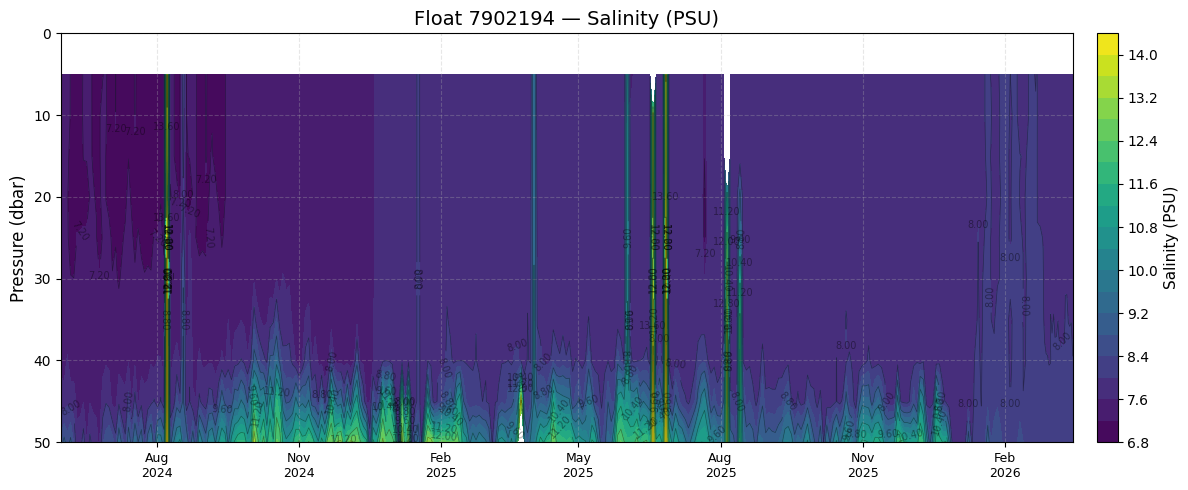

In [68]:
fig, ax = plt.subplots(figsize=(13, 5))

cf = ax.contourf(
    dates, pres_grid, psal_grid,
    levels=20,
    cmap='viridis'
)

cs = ax.contour(
    dates, pres_grid, psal_grid,
    levels=10,
    colors='k', linewidths=0.5, alpha=0.4
)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.2f')

ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), fontsize=9)

ax.set_ylabel('Pressure (dbar)', fontsize=12)
ax.set_title(f'Float {WMO} — Salinity (PSU)', fontsize=14)

cbar = fig.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label('Salinity (PSU)', fontsize=11)

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Describe any patterns you observe.**
When is the surface warmest/coldest? Is there a clear thermocline (sharp temperature
gradient with depth)? Does salinity show a seasonal signal, and at what depth?

*Your answer here:*
The water is the warmest around September and the coldest around March. Yes, there is a sharp thermocline around 25m in depth. There is higher salinity in the bottom as there is the salty water coming from the sea. It can be also seen in the Februaray 2026 that it was very cold and windy and that is why the whole both salinity and temperature stratification was gone. 

---
## Task 3 — Mixed Layer Depth from Density
Here it's going to get a bit more complicated.

You can estimate the depth of the mixed layer from the density of the seawater. This requires us to first estimate seawater density from temperature and salinity.
The first step, is to write a function that computes density from temperature and salinity.
### Step 3a — Density function

The simplified linear equation of state is:

$$\rho \approx 1000 + 0.8 \times S - 0.2 \times T \quad [\text{kg/m}^3]$$

where *S* is salinity (PSU) and *T* is temperature (°C).

In [69]:
def calculate_density(temp, psal):
    """
    Estimate seawater density using a linear approximation.

    Parameters
    ----------
    temp : float or array-like — temperature in degrees C
    psal : float or array-like — practical salinity in PSU

    Returns
    -------
    density in kg/m^3
    """
    # TODO: implement the formula above
    density = 1000 + 0.8 * psal - 0.2 * temp
    return density
    


# Quick check — typical surface seawater is ~1025 kg/m3
print(f'Test: T=15°C, S=35 PSU  →  {calculate_density(15, 35):.2f} kg/m³  (expect ≈ 1025)')

Test: T=15°C, S=35 PSU  →  1025.00 kg/m³  (expect ≈ 1025)


In [70]:
# Add a DENSITY column to the DataFrame using your function
# TODO: 
df['DENSITY'] = calculate_density(df['TEMP'], df['PSAL'])
pass

### Step 3b — MLD function

Check out notebook 2 for tips. Use the density gradient instead of temperature to define the MLD this time!

In [71]:
def calculate_mld(profile, threshold=0.2, ref_depth=10):
    """
    Calculate Mixed Layer Depth.
    """
    # TODO implement this function
    # Step 1: sort measurements from shallow to deep, makes our life easier
    profile = profile.sort_values('PRES').reset_index(drop=True)

    # Step 2: create a new data frame with measruments which are only +/- 5 dbar around the reference depth for this profile

    near_surface = profile[
        (profile['PRES'] >= ref_depth - 5) &
        (profile['PRES'] <= ref_depth + 5)
    ]

    # Step 3: (Optional, but a good backup) If there is no data around the reference depth, just take the shallowest data points
    if near_surface.empty:
        # Fall back to the shallowest available measurement
        near_surface = profile.iloc[[0]]

    # Step 4: Find the mean density around the reference depth of the profile
    T_ref = near_surface['DENSITY'].mean()

    # Step 5: (Optional, but good to have) if the mean density is empty, return nan (nothing)
    if np.isnan(T_ref):
        return np.nan

    # Step 6: Creat a new data frame with only the measurements above the threshold density for this profile
    mixed_layer = profile[profile['DENSITY'] >= T_ref - threshold]

    # Step 7: (Optional, but good to have) if there is no data above the threshold density, return nan (nothing)
    if mixed_layer.empty:
        return np.nan

    # Step 8: Return the deepest point in the mixed layer, i.e where the density fufills the criteria
    return mixed_layer['PRES'].max()


print('MLD function defined.')
print(f'Threshold used: 0.2 °C below the density at 10 dbar')


MLD function defined.
Threshold used: 0.2 °C below the density at 10 dbar


### Step 3c — Compute MLD for every profile

In [72]:
# Your code here
# Loop over every cycle and compute MLD
results = []

for cycle, group in df.groupby('CYCLE_NUMBER'):
    mld  = calculate_mld(group)
    date = group['DATE'].iloc[0]
    results.append({'CYCLE_NUMBER': cycle, 'DATE': date, 'MLD': mld})

mld_df = pd.DataFrame(results)

# Remove cycles where MLD could not be computed
mld_df = mld_df.dropna(subset=['MLD'])

print(f'MLD computed for {len(mld_df)} cycles.')
print(f'MLD range: {mld_df["MLD"].min():.0f} – {mld_df["MLD"].max():.0f} dbar')
mld_df.head()

MLD computed for 328 cycles.
MLD range: 48 – 80 dbar


,CYCLE_NUMBER,DATE,MLD
0,1,2024-05-30 23:28:30,78.699997
1,2,2024-06-02 01:28:00,79.500000
2,3,2024-06-04 03:26:30,78.800003
3,4,2024-06-06 05:26:00,78.699997
4,5,2024-06-08 07:31:30,77.500000


### Step 3d — Plot MLD over time

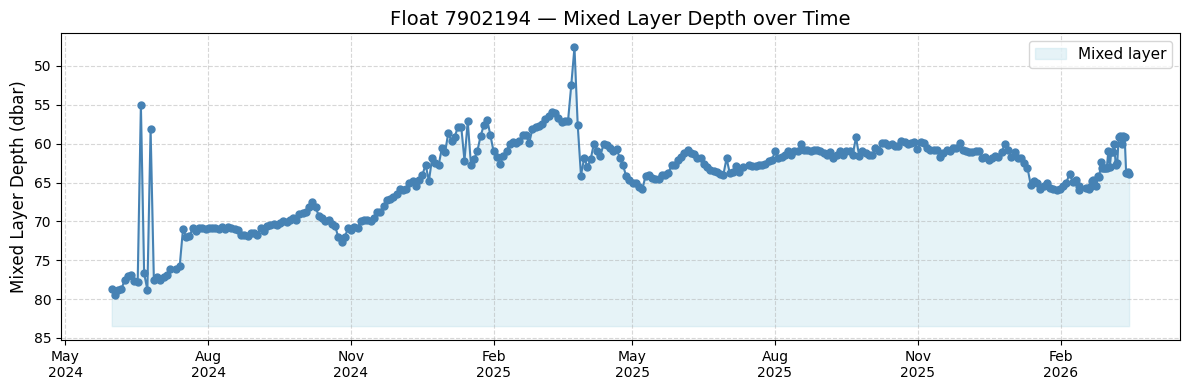

In [73]:
# Your code here, check out notebook 2
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(mld_df['DATE'], mld_df['MLD'],
        color='steelblue', linewidth=1.5, zorder=2)

ax.scatter(mld_df['DATE'], mld_df['MLD'],
           color='steelblue', s=25, zorder=3)

# Shade the area below the MLD line to make it visually clear
ax.fill_between(mld_df['DATE'], mld_df['MLD'], mld_df['MLD'].max() * 1.05,
                color='lightblue', alpha=0.3, label='Mixed layer')

ax.invert_yaxis()   # Surface at top
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax.set_ylabel('Mixed Layer Depth (dbar)', fontsize=12)
ax.set_title(f'Float {WMO} — Mixed Layer Depth over Time', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Describe the patterns in MLD.**



*Your answer here:*

---
## Task 4 — Average Mixed-Layer Properties Over Time

Knowing the MLD lets us average temperature and salinity *within* the mixed layer
for each profile, then track those averages over time. We'll start with showing an example function you could use to compute the averages. inside the MLD. After that it's up to you! You'll have to apply the function to each cycle, for each variable you are interested in, and then plot them.

### Step 4a — Mixed-layer averaging function

In [74]:
def mixed_layer_average(profile, mld, variable):
    """
    Return the depth-averaged value of a variable within the mixed layer.

    Parameters
    ----------
    profile  : DataFrame for one cycle, with columns 'PRES' and `variable`
    mld      : float — mixed layer depth in dbar
    variable : str   — column to average, e.g. 'TEMP' or 'PSAL'

    Returns
    -------
    mean value (float) or NaN if no data lies above the MLD
    """

    # Get the measurements that are inside the mixed layer (PRES <= mld)
    inside_mld = profile[profile['PRES'] <= mld]
    if inside_mld.empty:
        return np.nan

    return inside_mld[variable].mean()

In [75]:
# Calculate mixed-layer averages for each cycle
ml_results = []

# Loop over each cycle, get the profile, calculate MLD, and then compute the mixed-layer average for temperature and salinity
for _, row in mld_df.iterrows():
    cycle = row['CYCLE_NUMBER']
    mld = row['MLD']
    date = row['DATE']

    # Get the profile for this cycle
    profile = df[df['CYCLE_NUMBER'] == cycle]

    # Calculate the mixed-layer average for temperature and salinity
    ml_temp = mixed_layer_average(profile, mld, 'TEMP')
    ml_psal = mixed_layer_average(profile, mld, 'PSAL')

    ml_results.append({
        'CYCLE_NUMBER': cycle,
        'DATE': date,
        'MLD': mld,
        'ML_TEMP': ml_temp,
        'ML_PSAL': ml_psal
    })

ml_df = pd.DataFrame(ml_results).sort_values('DATE').reset_index(drop=True)

print(f'Mixed-layer averages computed for {len(ml_df)} cycles.')
ml_df.head()

Mixed-layer averages computed for 328 cycles.


,CYCLE_NUMBER,DATE,MLD,ML_TEMP,ML_PSAL
0,1,2024-05-30 23:28:30,78.699997,6.669937,9.521955
1,2,2024-06-02 01:28:00,79.500000,6.963804,9.467486
2,3,2024-06-04 03:26:30,78.800003,7.114662,9.382494
3,4,2024-06-06 05:26:00,78.699997,7.049831,9.041928
4,5,2024-06-08 07:31:30,77.500000,7.356329,8.904214


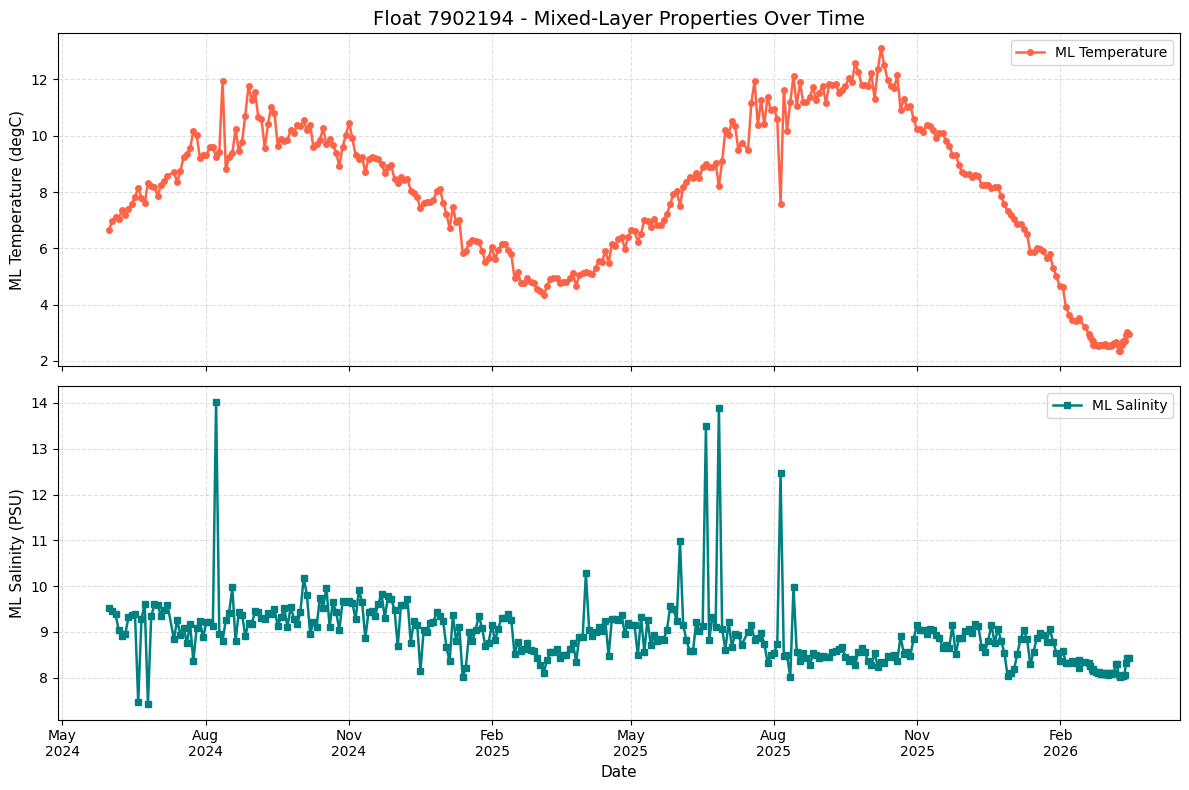

In [76]:
# Plot mixed-layer averages over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel: mixed-layer temperature
ax1.plot(
    ml_df['DATE'], ml_df['ML_TEMP'],
    color='tomato', linewidth=1.8, marker='o', markersize=4,
    label='ML Temperature'
 )
ax1.set_ylabel('ML Temperature (degC)', fontsize=11)
ax1.set_title(f'Float {WMO} - Mixed-Layer Properties Over Time', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(fontsize=10)

# Bottom panel: mixed-layer salinity
ax2.plot(
    ml_df['DATE'], ml_df['ML_PSAL'],
    color='teal', linewidth=1.8, marker='s', markersize=4,
    label='ML Salinity'
 )
ax2.set_ylabel('ML Salinity (PSU)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(fontsize=10)

# Format date ticks
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.tight_layout()
plt.show()

**Describe the patterns in mixed-layer temperature, salinity, and depth.**

*Your answer here:*



---
## Congratulations!
Done! Try exporting the notebook as a pdf and make sure it all looks good before submitting!